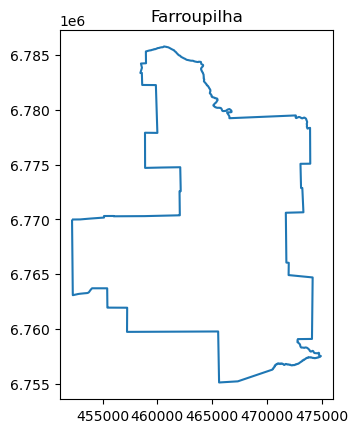

In [73]:
import geopandas
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

gdf_farroupilha = geopandas.read_file('/home/jovyan/work/data/input/params/far/lim_munic/Limite_Municipal.shp')
gdf_farroupilha_urb = geopandas.read_file('/home/jovyan/work/data/input/params/far/perimetro_urb/Perimetro_Urbano.shp')

gdf_farroupilha.plot()

plt.title("Farroupilha")

plt.show()

In [74]:
import os, sys
from pyspark.sql import SparkSession

sys.path.append(os.path.join(os.getcwd(), "/home/jovyan/work/src/pyspark_app"))

import session

spark = SparkSession.builder.getOrCreate()
url = session.jdbc_url()
props = session.jdbc_props()

table_name = "gps.points"

df = spark.read.jdbc(
    url=url,
    table=table_name,
    properties=props
)

df_points = df.toPandas()

<Axes: >

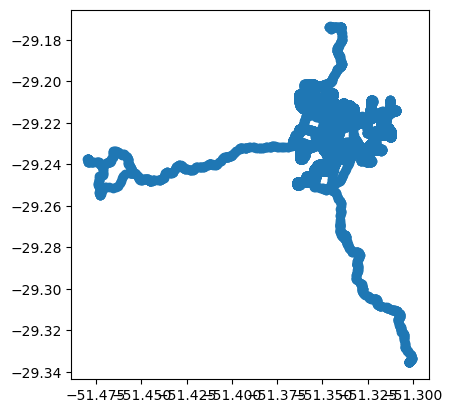

In [75]:
df_points['geometry'] = df_points.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

gdf_points = geopandas.GeoDataFrame(df_points, geometry='geometry', crs="EPSG:4326") # EPSG:31982

gdf_points.plot()

<Axes: >

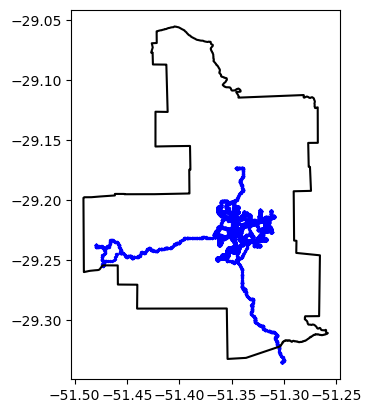

In [76]:
gdf_farroupilha = gdf_farroupilha.to_crs(gdf_points.crs)

ax = gdf_farroupilha.plot(color='black', edgecolor='black')
gdf_points.plot(ax=ax, color='blue', markersize=2)

In [77]:
poligono = gdf_farroupilha.geometry.union_all()

def in_perimeter(row):
    point = Point(row['lon'], row['lat'])
    return poligono.contains(point)

df_points['is_in_perimeter'] = df_points.apply(in_perimeter, axis=1)

In [78]:
df_points['is_in_perimeter']

0        False
1        False
2        False
3        False
4        False
         ...  
14945    False
14946    False
14947    False
14948    False
14949    False
Name: is_in_perimeter, Length: 14950, dtype: bool